# ML4 - Classification

## 1. Import, Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from category_encoders.count import CountEncoder 
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
training_data = pd.read_csv('../datasets/training.csv', index_col='RefId', parse_dates=['PurchDate'])

In [5]:
training_data.head(1)

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
RefId,,,,,,,,,,,,,,,,,,,,,
1,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113


In [6]:
training_data.columns

Index(['IsBadBuy', 'PurchDate', 'Auction', 'VehYear', 'VehicleAge', 'Make',
       'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID',
       'WheelType', 'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
       'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
       'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
       'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
       'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice',
       'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
       'IsOnlineSale', 'WarrantyCost'],
      dtype='object')

## 2. Train/valid/test split

- drop `VehYear` (collinear with `VehicleAge`), `WheelTypeID` (collinear with `WheelType`), `SubModel`

In [7]:
training_data = training_data.drop(['VehYear', 'WheelTypeID', 'SubModel'], axis=1)

- extract day of week and day of month from `PurchDate`

In [8]:
# training_data['day_of_week'] = training_data.PurchDate.dt.day_of_week
# training_data['day_of_month'] = training_data.PurchDate.dt.day

In [9]:
features = training_data.columns[1:]

- sort by `PurchDate` and split into 1/3 parts

In [10]:
size = len(training_data) // 3 + 1
sorted_by_purchdate = training_data.sort_values(by='PurchDate')
train = sorted_by_purchdate.iloc[:size]
valid = sorted_by_purchdate.iloc[size:size*2]
test = sorted_by_purchdate.iloc[size*2:]

In [11]:
train.PurchDate.iloc[0] < valid.PurchDate.iloc[0] < test.PurchDate.iloc[0]

True

In [12]:
train = train.drop(['PurchDate'], axis=1)
valid = valid.drop(['PurchDate'], axis=1)
test = test.drop(['PurchDate'], axis=1)

- split into X and y

In [13]:
X_train = train.drop(['IsBadBuy'], axis=1)
y_train = train['IsBadBuy']

X_valid = valid.drop(['IsBadBuy'], axis=1)
y_valid = valid['IsBadBuy']

X_test = test.drop(['IsBadBuy'], axis=1)
y_test = test['IsBadBuy']

## 3. Features preprocessing

In [14]:
categorical_features = ['Auction', 'Make', 'Model', 'Trim', 'Color', 'Transmission', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST']
numerical_features = list(set(features) - set(categorical_features) - {'IsOnlineSale', 'PurchDate', 'day_of_week', 'day_of_month'})

## OneHotEncoding

In [15]:
ohc = OneHotEncoder(use_cat_names=True, cols=categorical_features)

In [16]:
ohc.fit(X_train)
X_train = ohc.transform(X_train)
X_valid = ohc.transform(X_valid)
X_test = ohc.transform(X_test)

In [17]:
X_train.head(1)

,Auction_MANHEIM,Auction_OTHER,Auction_ADESA,VehicleAge,Make_CHRYSLER,Make_FORD,Make_DODGE,Make_CHEVROLET,Make_NISSAN,Make_KIA,...,VNST_NM,VNST_PA,VNST_NV,VNST_NE,VNST_NJ,VNST_KY,VNST_WA,VehBCost,IsOnlineSale,WarrantyCost
RefId,,,,,,,,,,,,,,,,,,,,,
32389,1,0,0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,6770.0,0,1389


In [18]:
X_test.head(1)

,Auction_MANHEIM,Auction_OTHER,Auction_ADESA,VehicleAge,Make_CHRYSLER,Make_FORD,Make_DODGE,Make_CHEVROLET,Make_NISSAN,Make_KIA,...,VNST_NM,VNST_PA,VNST_NV,VNST_NE,VNST_NJ,VNST_KY,VNST_WA,VehBCost,IsOnlineSale,WarrantyCost
RefId,,,,,,,,,,,,,,,,,,,,,
60275,0,0,1,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,7915.0,0,594


## StandardScaler


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
ssc = StandardScaler()

In [21]:
ssc.fit(X_train[numerical_features])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [22]:
X_train[numerical_features] = ssc.transform(X_train[numerical_features])
X_valid[numerical_features] = ssc.transform(X_valid[numerical_features])
X_test[numerical_features] = ssc.transform(X_test[numerical_features])

In [23]:
X_train.head(1)

,Auction_MANHEIM,Auction_OTHER,Auction_ADESA,VehicleAge,Make_CHRYSLER,Make_FORD,Make_DODGE,Make_CHEVROLET,Make_NISSAN,Make_KIA,...,VNST_NM,VNST_PA,VNST_NV,VNST_NE,VNST_NJ,VNST_KY,VNST_WA,VehBCost,IsOnlineSale,WarrantyCost
RefId,,,,,,,,,,,,,,,,,,,,,
32389,1,0,0,-1.357282,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0.231374,0,0.113708


In [24]:
X_test.head(1)

,Auction_MANHEIM,Auction_OTHER,Auction_ADESA,VehicleAge,Make_CHRYSLER,Make_FORD,Make_DODGE,Make_CHEVROLET,Make_NISSAN,Make_KIA,...,VNST_NM,VNST_PA,VNST_NV,VNST_NE,VNST_NJ,VNST_KY,VNST_WA,VehBCost,IsOnlineSale,WarrantyCost
RefId,,,,,,,,,,,,,,,,,,,,,
60275,0,0,1,1.137426,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.872243,0,-1.191759


## NA imputation

In [25]:
na_columns = X_train.columns[np.where(X_train.isna().sum() > 0)]

In [26]:
imputer = SimpleImputer(strategy='mean')

In [27]:
imputer.fit(X_train[na_columns])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [28]:
X_train[na_columns] = imputer.transform(X_train[na_columns])
X_valid[na_columns] = imputer.transform(X_valid[na_columns])
X_test[na_columns] = imputer.transform(X_test[na_columns])

In [29]:
X_train.head(1)

,Auction_MANHEIM,Auction_OTHER,Auction_ADESA,VehicleAge,Make_CHRYSLER,Make_FORD,Make_DODGE,Make_CHEVROLET,Make_NISSAN,Make_KIA,...,VNST_NM,VNST_PA,VNST_NV,VNST_NE,VNST_NJ,VNST_KY,VNST_WA,VehBCost,IsOnlineSale,WarrantyCost
RefId,,,,,,,,,,,,,,,,,,,,,
32389,1,0,0,-1.357282,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0.231374,0,0.113708


#

# 4. Models Training

## Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [31]:
LR_clf = LogisticRegression(max_iter=500)

In [32]:
LR_clf.fit(X=X_train, y=y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
LR_probas = LR_clf.predict_proba(X_valid)[:, 1]

$$\large
{Gini = {ROC AUC} * 2 - 1}
$$

In [34]:
2 * roc_auc_score(y_true=y_valid, y_score=LR_probas) - 1

0.40060483644554457

## Gaussian Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB

In [36]:
GNB_clf = GaussianNB()

In [37]:
GNB_clf.fit(X=X_train, y=y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [38]:
GNB_probas = GNB_clf.predict_proba(X_valid)[:, 1]

In [39]:
GNB_probas

array([1., 1., 1., ..., 0., 1., 0.], shape=(24328,))

In [40]:
2 * roc_auc_score(y_true=y_valid, y_score=GNB_probas) - 1

0.0664498142374248

- GaussianNB is suited to work with continuous numerical variables (which are assumed to be distributed normally to evaluate likelihoods in MAP)
- **but** in our case most features are binary after one-hot encoding
- so GaussianNB assumptions are violated, and because of it `predict_proba` works inadequately

## Bernoulli Naive Bayes

In [41]:
bern_clf = BernoulliNB()

In [42]:
bern_clf.fit(X=X_train, y=y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [43]:
bern_probas = bern_clf.predict_proba(X_valid)[:, 1]

In [44]:
bern_probas

array([1.33783530e-02, 2.46719334e-04, 2.94364118e-04, ...,
       3.86568003e-03, 2.72656678e-01, 1.77374652e-02], shape=(24328,))

In [45]:
2 * roc_auc_score(y_true=y_valid, y_score=bern_probas) - 1

0.361766985107693

- as expected, Bernoulli Naive Bayes worked much better for our One-Hot encoded data

## K-Nearest Neighbours

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
KNN_clf = KNeighborsClassifier()

In [48]:
KNN_clf.fit(X=X_train, y=y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [49]:
KNN_probas = KNN_clf.predict_proba(X_valid)[:, 1]

In [50]:
KNN_probas

array([0.2, 0. , 0. , ..., 0. , 0.2, 0. ], shape=(24328,))

In [51]:
2 * roc_auc_score(y_true=y_valid, y_score=KNN_probas) - 1

0.20921396529803626

#### overall, **Logistic Regression** has the best Gini score on validation set, since it is specially designed to calculate probabilities, not just to classify with hard labels like NB and KNN
(and Gini and ROC AUC score evaluate the ability of the model to range samples properly by their probabilities) 

# 5. ROC AUC and Gini implementation

<img src="../misc/images/AUC-ROC-curve.png" alt="alt text" width="400"/>

In [52]:
from my_classification import my_gini

In [53]:
print(f"my_gini on logistic regression: {my_gini(y_true=y_valid, y_score=LR_probas):.3}\
        \nsklearn : {abs(2 * roc_auc_score(y_true=y_valid, y_score=LR_probas) - 1):.3}")

my_gini on logistic regression: 0.401        
sklearn : 0.401


In [54]:
print(f"my_gini on GaussianNB {my_gini(y_true=y_valid, y_score=GNB_probas):.3}\
        \nsklearn : {abs(2 * roc_auc_score(y_true=y_valid, y_score=GNB_probas) - 1):.3}")

my_gini on GaussianNB 0.0521        
sklearn : 0.0664


In [55]:
print(f"my_gini on BernoulliNB {my_gini(y_true=y_valid, y_score=bern_probas):.3}\
        \nsklearn : {abs(2 * roc_auc_score(y_true=y_valid, y_score=bern_probas) - 1):.3}")

my_gini on BernoulliNB 0.362        
sklearn : 0.362


In [56]:
print(f"my_gini on KNN: {my_gini(y_true=y_valid, y_score=KNN_probas):.3}\
        \nsklearn : {abs(2 * roc_auc_score(y_true=y_valid, y_score=KNN_probas) - 1):.3}")

my_gini on KNN: 0.187        
sklearn : 0.209


- overall, `my_gini` gives almost the same result as sklearn `roc_auc_score`-based implementation

#

# 6. Logistic Regression, KNN, NaiveBayes implementations

## LogReg

In [57]:
from my_classification import MyLogisticRegression

Epoch 0, Loss: 0.3298
Epoch 2, Loss: 0.3173
Epoch 4, Loss: 0.3095
Epoch 6, Loss: 0.3045
Epoch 8, Loss: 0.3011
Epoch 10, Loss: 0.2987
Epoch 12, Loss: 0.2970
Epoch 14, Loss: 0.2957


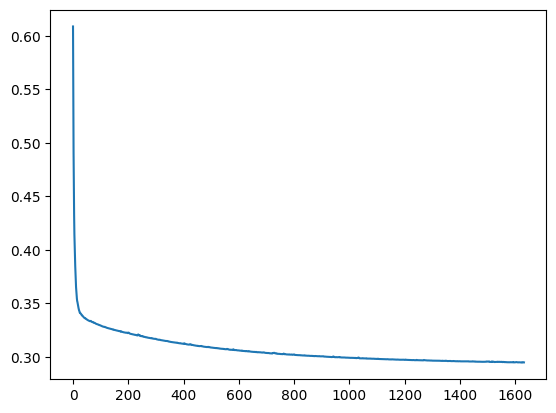

In [58]:
my_LR = MyLogisticRegression()
my_LR.fit(X_train=X_train, y_train=y_train)
plt.plot(my_LR.loss_by_epoch)

In [59]:
my_LR.predict_proba(X_test=X_valid)

array([[0.90785777, 0.09214223],
       [0.91974584, 0.08025416],
       [0.95332059, 0.04667941],
       ...,
       [0.93469765, 0.06530235],
       [0.85151352, 0.14848648],
       [0.92319659, 0.07680341]], shape=(24328, 2))

In [60]:
my_LR.predict(X_test=X_valid)

array([0, 0, 0, ..., 0, 0, 0], shape=(24328,))

In [61]:
my_LR_probas = my_LR.predict_proba(X_test=X_valid)[:, 1]
print(f"my_gini on MyLogisticRegression: {my_gini(y_true=y_valid, y_score=my_LR_probas):.3}\
        \nsklearn gini: {abs(2 * roc_auc_score(y_true=y_valid, y_score=my_LR_probas) - 1):.3}")
print()
print(f"my_gini on sklearn LogisticRegression: {my_gini(y_true=y_valid, y_score=LR_probas):.3}")

my_gini on MyLogisticRegression: 0.489        
sklearn gini: 0.489

my_gini on sklearn LogisticRegression: 0.401


- default MyLogisticRegression performed even better than default sklearn LogisticRegression (I have tweaked MyLR defaults)

## KNN

In [62]:
from my_classification import MyKNNCLassifier

In [63]:
my_KNN = MyKNNCLassifier()

In [64]:
my_KNN.fit(X_train=X_train, y_train=y_train)

In [65]:
my_KNN.predict_proba(X_test=X_valid)

array([[0.8, 0.2],
       [1. , 0. ],
       [1. , 0. ],
       ...,
       [1. , 0. ],
       [0.8, 0.2],
       [1. , 0. ]], shape=(24328, 2))

In [66]:
my_KNN.predict(X_test=X_valid)

array([0, 0, 0, ..., 0, 0, 0], shape=(24328,))

In [67]:
my_KNN_probas = my_KNN.predict_proba(X_test=X_valid)[:, 1]
print(f"my_gini on MyKNN: {my_gini(y_true=y_valid, y_score=my_KNN_probas):.3}\
        \nsklearn gini: {abs(2 * roc_auc_score(y_true=y_valid, y_score=my_KNN_probas) - 1):.3}")
print()
print(f"my_gini on sklearn KNN: {my_gini(y_true=y_valid, y_score=KNN_probas):.3}")

my_gini on MyKNN: 0.187        
sklearn gini: 0.209

my_gini on sklearn KNN: 0.187


- MyKNN produced exactly the same gini score as sklearn KNN

## Mixed Naive Bayes

In [68]:
from my_classification import MyMixedNB

In [69]:
my_MixedNB = MyMixedNB()

In [70]:
my_MixedNB.fit(X_train=X_train, y_train=y_train)

In [71]:
np.vectorize(lambda x: f"{x:0.5f}")(my_MixedNB.predict_proba(X_test=X_valid))

array([['0.98102', '0.01898'],
       ['0.99905', '0.00095'],
       ['0.99956', '0.00044'],
       ...,
       ['0.99206', '0.00794'],
       ['0.78113', '0.21887'],
       ['0.98862', '0.01138']], shape=(24328, 2), dtype='<U7')

In [72]:
my_MixedNB.predict(X_test=X_valid)

array([0, 0, 0, ..., 0, 0, 0], shape=(24328,))

In [73]:
my_MixedNB_probas = my_MixedNB.predict_proba(X_test=X_valid)[:, 1]
print(f"my_gini on MyMixedNB: {my_gini(y_true=y_valid, y_score=my_MixedNB_probas):.3}\
        \nsklearn gini: {abs(2 * roc_auc_score(y_true=y_valid, y_score=my_MixedNB_probas) - 1):.3}")
print()
print(f"my_gini on sklearn BernoulliNB {my_gini(y_true=y_valid, y_score=bern_probas):.3}")

my_gini on MyMixedNB: 0.38        
sklearn gini: 0.38

my_gini on sklearn BernoulliNB 0.362


- MyMixedNB performed even better than sklearn Bernoulli NB since both binary and numerical features are taken into account properly

#

# 7. Feature Engineering

In [74]:
def create_new_features_safe(train_df, test_df=None):
    """
    Create new features while preventing data leakage.
    Returns only new features calculated properly for train/test.
    
    Parameters:
    -----------
    train_df : pandas.DataFrame
        Training dataframe
    test_df : pandas.DataFrame, optional
        Test dataframe
    
    Returns:
    --------
    train_features, test_features (or just train_features if test_df is None)
    """
    
    # Create empty dataframes for new features
    train_features = pd.DataFrame(index=train_df.index)
    
    # Calculate statistics ONLY from training data
    state_risk = train_df.groupby('VNST')['IsBadBuy'].mean()
    color_popularity = train_df['Color'].value_counts(normalize=True)
    make_counts = train_df['Make'].value_counts()
    model_counts = train_df['Model'].value_counts()
    buyer_counts = train_df['BYRNO'].value_counts()
    
    # 1. Price ratio features (no leakage risk)
    train_features['price_ratio'] = train_df['VehBCost'] / train_df['MMRCurrentRetailAveragePrice']
    train_features['auction_discount'] = train_df['VehBCost'] / train_df['MMRAcquisitionAuctionAveragePrice']
    train_features['price_appreciation'] = train_df['MMRCurrentAuctionAveragePrice'] / train_df['MMRAcquisitionAuctionAveragePrice']
    train_features['retail_appreciation'] = train_df['MMRCurrentRetailAveragePrice'] / train_df['MMRAcquisitionRetailAveragePrice']
    
    # 2. Vehicle usage features
    train_features['usage_intensity'] = train_df['VehOdo'] / (train_df['VehicleAge'] + 0.001)
    train_features['mileage_per_cost'] = train_df['VehOdo'] / (train_df['VehBCost'] + 1000)
    
    # 3. Warranty feature
    train_features['warranty_ratio'] = train_df['WarrantyCost'] / (train_df['VehBCost'] + 0.001)
    
    # 4. Geographic features
    train_features['zip_region'] = train_df['VNZIP1'].astype(str).str[0].astype(int)
    train_features['state_risk_score'] = train_df['VNST'].map(state_risk)
    
    # 5. Vehicle popularity features
    train_features['make_frequency'] = train_df['Make'].map(make_counts)
    train_features['model_rarity'] = 1 / (train_df['Model'].map(model_counts) + 1)
    train_features['color_commonality'] = train_df['Color'].map(color_popularity)
    
    # 6. Buyer experience
    train_features['buyer_experience'] = train_df['BYRNO'].map(buyer_counts)
    
    # Clean up infinite values
    train_features = train_features.replace([np.inf, -np.inf], np.nan)
    
    # Process test data if provided
    if test_df is not None:
        test_features = pd.DataFrame(index=test_df.index)
        
        # Features without leakage risk
        test_features['price_ratio'] = test_df['VehBCost'] / test_df['MMRCurrentRetailAveragePrice']
        test_features['auction_discount'] = test_df['VehBCost'] / test_df['MMRAcquisitionAuctionAveragePrice']
        test_features['price_appreciation'] = test_df['MMRCurrentAuctionAveragePrice'] / test_df['MMRAcquisitionAuctionAveragePrice']
        test_features['retail_appreciation'] = test_df['MMRCurrentRetailAveragePrice'] / test_df['MMRAcquisitionRetailAveragePrice']
        test_features['usage_intensity'] = test_df['VehOdo'] / (test_df['VehicleAge'] + 0.001)
        test_features['mileage_per_cost'] = test_df['VehOdo'] / (test_df['VehBCost'] + 1000)
        test_features['warranty_ratio'] = test_df['WarrantyCost'] / (test_df['VehBCost'] + 0.001)
        test_features['zip_region'] = test_df['VNZIP1'].astype(str).str[0].astype(int)
        
        # Features using training statistics (to prevent leakage)
        test_features['state_risk_score'] = test_df['VNST'].map(state_risk)
        test_features['make_frequency'] = test_df['Make'].map(make_counts)
        test_features['model_rarity'] = 1 / (test_df['Model'].map(model_counts) + 1)
        test_features['color_commonality'] = test_df['Color'].map(color_popularity)
        test_features['buyer_experience'] = test_df['BYRNO'].map(buyer_counts)
        
        # Clean up infinite values
        test_features = test_features.replace([np.inf, -np.inf], np.nan)
        
        return train_features, test_features
    
    return train_features


def impute_and_scale_features(train_features, test_features=None):
    """
    Impute missing values and scale features.
    All transformations are fitted on training data only.
    
    Parameters:
    -----------
    train_features : pandas.DataFrame
        Training features
    test_features : pandas.DataFrame, optional
        Test features
    
    Returns:
    --------
    imputed_scaled_train, imputed_scaled_test (or just train if test is None)
    """
    
    # Store column names and indices
    train_columns = train_features.columns
    train_index = train_features.index
    
    # 1. Impute missing values with mean (fit on train only)
    imputer = SimpleImputer(strategy='mean')
    train_imputed = imputer.fit_transform(train_features)
    
    # Convert back to DataFrame
    train_imputed = pd.DataFrame(
        train_imputed, 
        columns=train_columns, 
        index=train_index
    )
    
    # 2. Scale features (fit on train only)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_imputed)
    
    # Convert back to DataFrame
    train_final = pd.DataFrame(
        train_scaled, 
        columns=train_columns, 
        index=train_index
    )
    
    # Process test data if provided
    if test_features is not None:
        test_columns = test_features.columns
        test_index = test_features.index
        
        # 1. Impute using SAME imputer fitted on train
        test_imputed = imputer.transform(test_features)
        test_imputed = pd.DataFrame(
            test_imputed, 
            columns=test_columns, 
            index=test_index
        )
        
        # 2. Scale using SAME scaler fitted on train
        test_scaled = scaler.transform(test_imputed)
        test_final = pd.DataFrame(
            test_scaled, 
            columns=test_columns, 
            index=test_index
        )
        
        return train_final, test_final
    
    return train_final


def complete_feature_pipeline(train_df, test_df=None):
    """
    Complete pipeline: create features → impute → scale
    
    Parameters:
    -----------
    train_df : pandas.DataFrame
        Training dataframe
    test_df : pandas.DataFrame, optional
        Test dataframe
    
    Returns:
    --------
    train_processed, test_processed (or just train if test is None)
    """
    
    # Step 1: Create new features (safely)
    if test_df is not None:
        train_features, test_features = create_new_features_safe(train_df, test_df)
        
        # Step 2: Impute and scale
        train_processed, test_processed = impute_and_scale_features(train_features, test_features)
        
        return train_processed, test_processed
    else:
        train_features = create_new_features_safe(train_df)
        
        # Step 2: Impute and scale
        train_processed = impute_and_scale_features(train_features)
        
        return train_processed

In [75]:
train_new_features, valid_new_features = complete_feature_pipeline(train_df=train, test_df=valid)
train_new_features, test_new_features = complete_feature_pipeline(train_df=train, test_df=test)

In [76]:
X_train_ohc_enriched = pd.concat([X_train, train_new_features], axis=1)
X_valid_ohc_enriched = pd.concat([X_valid, valid_new_features], axis=1)

### old features vs. new features (*with One Hot Encoding*)

In [ ]:
print("SKLEARN MODELS, One-Hot encoded categoricals\n")

LR_clf.fit(X_train, y_train)
print(f"logistic regression, my_gini on old features: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid)[:, 1]):.3f}")
LR_clf.fit(X_train_ohc_enriched, y_train)
print(f"logistic regression, my_gini on new features: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_ohc_enriched)[:, 1]):.3f}")

print()

bern_clf.fit(X_train, y_train)
print(f"Bernoulli Naive Bayes, my_gini on old features: {my_gini(y_true=y_valid, y_score=bern_clf.predict_proba(X_valid)[:, 1]):.3f}")
bern_clf.fit(X_train_ohc_enriched, y_train)
print(f"Bernoulli Naive Bayes, my_gini on new features: {my_gini(y_true=y_valid, y_score=bern_clf.predict_proba(X_valid_ohc_enriched)[:, 1]):.3f}")

print()

KNN_clf.fit(X_train, y_train)
print(f"KNN, my_gini on old features: {my_gini(y_true=y_valid, y_score=KNN_clf.predict_proba(X_valid)[:, 1]):.3f}")
KNN_clf.fit(X_train_ohc_enriched, y_train)
print(f"KNN, my_gini on new features: {my_gini(y_true=y_valid, y_score=KNN_clf.predict_proba(X_valid_ohc_enriched)[:, 1]):.3f}")


print("\nMY MODELS, One-Hot encoded categoricals\n")

my_LR = MyLogisticRegression(log_freq=0)
my_LR.fit(X_train, y_train)
print(f"MyLogisticRegression, my_gini on old features: {my_gini(y_true=y_valid, y_score=my_LR.predict_proba(X_valid)[:, 1]):.3f}")
my_LR.fit(X_train_ohc_enriched, y_train)
print(f"MyLogisticRegression, my_gini on new features: {my_gini(y_true=y_valid, y_score=my_LR.predict_proba(X_valid_ohc_enriched)[:, 1]):.3f}")

print()

my_MixedNB.fit(X_train, y_train)
print(f"MyMixedNB, my_gini on old features: {my_gini(y_true=y_valid, y_score=my_MixedNB.predict_proba(X_valid)[:, 1]):.3f}")
my_MixedNB.fit(X_train_ohc_enriched, y_train)
print(f"MyMixedNB, my_gini on new features: {my_gini(y_true=y_valid, y_score=my_MixedNB.predict_proba(X_valid_ohc_enriched)[:, 1]):.3f}")

print()

my_KNN.fit(X_train, y_train)
print(f"MyKNN, my_gini on old features: {my_gini(y_true=y_valid, y_score=my_KNN.predict_proba(X_valid)[:, 1]):.3f}")
my_KNN.fit(X_train_ohc_enriched, y_train)
print(f"MyKNN, my_gini on new features: {my_gini(y_true=y_valid, y_score=my_KNN.predict_proba(X_valid_ohc_enriched)[:, 1]):.3f}")

SKLEARN MODELS, One-Hot encoded categoricals

logistic regression, my_gini on old features: 0.401
logistic regression, my_gini on new features: 0.411

Bernoulli Naive Bayes, my_gini on old features: 0.362
Bernoulli Naive Bayes, my_gini on new features: 0.363

KNN, my_gini on old features: 0.187
KNN, my_gini on new features: 0.140

MY MODELS, One-Hot encoded categoricals

MyLogisticRegression, my_gini on old features: 0.489


- using OneHotEncoding on all categorical features leads to high dimensionality (~1200 columns), which results in:
    - new features having marginal impact on gini score in case of sklearn models
    - impossible to evaluate the importance of a feature using coefficients of a model (for part 8)
- my implementations perofomed even worse with new features
- so it is worth trying a different type of encoding to preserve low dimensionality

### old features vs. new features (*with Count Encoding*)

In [ ]:
count_enc = CountEncoder()

In [ ]:
# count encoding
X_train_count = count_enc.fit_transform(train.drop('IsBadBuy', axis=1))
X_valid_count = count_enc.transform(valid.drop('IsBadBuy', axis=1))

In [ ]:
# standard scaler
X_train_count = pd.DataFrame(ssc.fit_transform(X_train_count), columns=X_train_count.columns)
X_valid_count = pd.DataFrame(ssc.transform(X_valid_count), columns=X_valid_count.columns)

In [ ]:
# NaN imputation
X_train_count = pd.DataFrame(imputer.fit_transform(X_train_count), columns=X_train_count.columns)
X_valid_count = pd.DataFrame(imputer.transform(X_valid_count), columns=X_valid_count.columns)

In [ ]:
X_train_count_enriched = pd.concat([X_train_count.set_index(train_new_features.index), train_new_features], axis=1)
X_valid_count_enriched = pd.concat([X_valid_count.set_index(valid_new_features.index), valid_new_features], axis=1)

In [ ]:
print("SKLEARN MODELS, Count encoded categoricals\n")

LR_clf.fit(X_train_count, y_train)
print(f"logistic regression, my_gini on old features: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_count)[:, 1]):.3f}")
LR_clf.fit(X_train_count_enriched, y_train)
print(f"logistic regression, my_gini on new features: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")

print()

GNB_clf.fit(X_train_count, y_train)
print(f"Gaussian Naive Bayes, my_gini on old features: {my_gini(y_true=y_valid, y_score=GNB_clf.predict_proba(X_valid_count)[:, 1]):.3f}")
GNB_clf.fit(X_train_count_enriched, y_train)
print(f"Gaussian Naive Bayes, my_gini on new features: {my_gini(y_true=y_valid, y_score=GNB_clf.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")

print()

KNN_clf.fit(X_train_count, y_train)
print(f"KNN, my_gini on old features: {my_gini(y_true=y_valid, y_score=KNN_clf.predict_proba(X_valid_count)[:, 1]):.3f}")
KNN_clf.fit(X_train_count_enriched, y_train)
print(f"KNN, my_gini on new features: {my_gini(y_true=y_valid, y_score=KNN_clf.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")


print("\nMY MODELS, Count encoded categoricals\n")

my_LR = MyLogisticRegression(log_freq=0)
my_LR.fit(X_train_count, y_train)
print(f"MyLogisticRegression, my_gini on old features: {my_gini(y_true=y_valid, y_score=my_LR.predict_proba(X_valid_count)[:, 1]):.3f}")
my_LR.fit(X_train_count_enriched, y_train)
print(f"MyLogisticRegression, my_gini on new features: {my_gini(y_true=y_valid, y_score=my_LR.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")

print()

my_MixedNB.fit(X_train_count, y_train)
print(f"MyMixedNB, my_gini on old features: {my_gini(y_true=y_valid, y_score=my_MixedNB.predict_proba(X_valid_count)[:, 1]):.3f}")
my_MixedNB.fit(X_train_count_enriched, y_train)
print(f"MyMixedNB, my_gini on new features: {my_gini(y_true=y_valid, y_score=my_MixedNB.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")

print()

my_KNN.fit(X_train_count, y_train)
print(f"MyKNN, my_gini on old features: {my_gini(y_true=y_valid, y_score=my_KNN.predict_proba(X_valid_count)[:, 1]):.3f}")
my_KNN.fit(X_train_count_enriched, y_train)
print(f"MyKNN, my_gini on new features: {my_gini(y_true=y_valid, y_score=my_KNN.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")

- for count-encoded features, adding new features decreased gini score for models
- but compared to one-hot encoding, all models permormed notably better (except for MyLogisticRegression since it was tweaked)

#

# 8. Features selection

### manual selection

1. fit MyLogisticRegression on count-encoded dataset

In [ ]:
my_LR.fit(X_train_count_enriched, y_train)
my_LR_weights = my_LR.coef_
my_LR_features_seen = X_train_count_enriched.columns

In [ ]:
my_LR_features_weights = np.abs(pd.DataFrame(my_LR_weights, index=my_LR_features_seen)).sort_values(by=0, ascending=False)

In [ ]:
plt.figure(figsize=(18, 5))
plt.bar(my_LR_features_weights.index, my_LR_features_weights.values.reshape(-1))
plt.xticks(rotation=45, ha="right");

2. fit sklearn LogisticRegression on count-encoded dataset

In [ ]:
LR_clf.fit(X_train_count_enriched, y_train)
LR_weights = LR_clf.coef_[0]
LR_features_seen = X_train_count_enriched.columns

In [ ]:
LR_features_weights = np.abs(pd.DataFrame(LR_weights, index=LR_features_seen)).sort_values(by=0, ascending=False)

In [ ]:
plt.figure(figsize=(18, 5))
plt.bar(LR_features_weights.index, LR_features_weights.values.reshape(-1))
plt.xticks(rotation=45, ha="right");

- sklearn LogisticRegression uses L2 regularization by default, so **weights are more balanced between features**
- sklearn LogRed feature weights are more suitable for feature selection then

In [ ]:
manual_selected_features = LR_features_weights[:20].index

### L1 regularization

In [ ]:
LR_clf_L1 = LogisticRegression(penalty='l1', C=0.1, solver='liblinear')
LR_clf_L1.fit(X_train_count_enriched, y_train)
LR_L1_weights = LR_clf_L1.coef_[0]
LR_L1_features_seen = X_train_count_enriched.columns

In [ ]:
LR_L1_features_weights = np.abs(pd.DataFrame(LR_L1_weights, index=LR_L1_features_seen)).sort_values(by=0, ascending=False)

In [ ]:
plt.figure(figsize=(18, 5))
plt.bar(LR_L1_features_weights.index, LR_L1_features_weights.values.reshape(-1))
plt.xticks(rotation=45, ha="right");

In [ ]:
L1_selected_features = LR_L1_features_weights[:20].index 

In [ ]:
set(manual_selected_features) & set(L1_selected_features)

- among top-20 features got from manual and L1 selection, 12 features are in both groups

### Gini score comparison

In [ ]:
# LR_clf = MyLogisticRegression(log_freq=0)
LR_clf = LogisticRegression()

LR_clf.fit(X_train_count_enriched, y_train)
print(f"LogisticRegression on full data: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_count_enriched)[:, 1]):.3f}")

LR_clf.fit(X_train_count_enriched[manual_selected_features], y_train)
print(f"LogisticRegression on manually selected features: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1]):.3f}")

LR_clf.fit(X_train_count_enriched[L1_selected_features], y_train)
print(f"LogisticRegression on L1 regularization selected features: {my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_count_enriched[L1_selected_features])[:, 1]):.3f}")

- selecting features worked for **manual selection, which gave great improvement**

# 9. Tweaking hyperparameters

- use sklearn LogisticRegression since it has more hyperparameters to try

In [ ]:
LR_clf = LogisticRegression()
LR_clf.fit(X_train_count_enriched[manual_selected_features], y_train)
baseline_score = my_gini(y_true=y_valid, y_score=LR_clf.predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1])

In [ ]:
C_list = [0.01, 0.1, 1, 10, 100]
max_iter_list = [100, 500, 1000]
penalty_list = [{'penalty': None},
                {'penalty':'l1', 'solver': 'saga'},
                {'penalty': 'l2'},
                {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5}]
class_weights = [None, 'balanced']

In [ ]:
C_ginis = [my_gini(y_true=y_valid, y_score=LogisticRegression(C=C).fit(X_train_count_enriched[manual_selected_features], y_train).predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1]) for C in C_list]
max_iter_ginis = [my_gini(y_true=y_valid, y_score=LogisticRegression(max_iter=max_iter).fit(X_train_count_enriched[manual_selected_features], y_train).predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1]) for max_iter in max_iter_list]
penalties_ginis = [my_gini(y_true=y_valid, y_score=LogisticRegression(**penalty).fit(X_train_count_enriched[manual_selected_features], y_train).predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1]) for penalty in penalty_list]
class_weights_ginis = [my_gini(y_true=y_valid, y_score=LogisticRegression(class_weight=class_weight).fit(X_train_count_enriched[manual_selected_features], y_train).predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1]) for class_weight in class_weights]

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].plot(C_list, C_ginis)
axes[0].set(title='C (regularization coefficient)', xscale='log', xticks=C_list)
axes[0].axhline(y=baseline_score, color="red", linestyle="--", linewidth=1);

axes[1].plot(max_iter_list, max_iter_ginis)
axes[1].set(title='max_iter', xticks=max_iter_list)
axes[1].axhline(y=baseline_score, color="red", linestyle="--", linewidth=1);

axes[2].plot(['no penalty', 'l1', 'l2', 'elasticnet'], penalties_ginis)
axes[2].set(title='penalty')
axes[2].axhline(y=baseline_score, color="red", linestyle="--", linewidth=1);

axes[3].plot(list(map(str, class_weights)), class_weights_ginis)
axes[3].set(title='class_weight')
axes[3].axhline(y=baseline_score, color="red", linestyle="--", linewidth=1);


- regularization coefficient, penalty and class_weight produced impact on gini score
- **regularization coefficient has the most effect**

### Grid search

In [ ]:
from itertools import product
from tqdm.notebook import tqdm

In [ ]:
best_score = baseline_score 
best_clf = LogisticRegression()
total = len(C_list) * len(penalty_list) * len(class_weights) * len(max_iter_list)

for C, max_iter, penalty, class_weight in tqdm(product(C_list, max_iter_list, penalty_list, class_weights), total=total):

    clf = LogisticRegression(C=C, max_iter=max_iter, class_weight=class_weight, **penalty)
    clf.fit(X_train_count_enriched[manual_selected_features], y_train)
    score = my_gini(y_true=y_valid, y_score=clf.predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1])
    
    if score > baseline_score:
        best_score = score
        best_clf = clf

In [ ]:
best_clf

In [ ]:
best_score

# 10. Overfit check on test

In [ ]:
X_test_count = count_enc.transform(test.drop('IsBadBuy', axis=1))
X_test_count = pd.DataFrame(ssc.transform(X_test_count), columns=X_test_count.columns)
X_test_count = pd.DataFrame(imputer.transform(X_test_count), columns=X_test_count.columns)
X_test_count_enriched = pd.concat([X_test_count.set_index(test_new_features.index), test_new_features], axis=1)

In [ ]:
print("classfier with tweaked hyperparams")
print(f"train gini: {my_gini(y_true=y_train, y_score=best_clf.predict_proba(X_train_count_enriched[manual_selected_features])[:, 1])}")
print(f"valid gini: {my_gini(y_true=y_valid, y_score=best_clf.predict_proba(X_valid_count_enriched[manual_selected_features])[:, 1])}")
print(f"test gini: {my_gini(y_true=y_valid, y_score=best_clf.predict_proba(X_test_count_enriched[manual_selected_features])[:, 1])}")

#### a massive drop in score occured on test compared to validation set -> **the model is terribly overfitted!**

# 11. Other metrics implemetation

In [ ]:
X_train = X_train_count_enriched[manual_selected_features]
X_test = X_test_count_enriched[manual_selected_features]

### Precision

In [ ]:
from my_classification import my_precision_score
from sklearn.metrics import precision_score

In [ ]:
my_KNN.fit(X_train=X_train, y_train=y_train)
my_KNN_predict = my_KNN.predict(X_test)
my_KNN_probas = my_KNN.predict_proba(X_test)[:, 1]

In [ ]:
my_LR = MyLogisticRegression(log_freq=0)
my_LR.fit(X_train, y_train)
print(f"MyLogisticRegression\nmy_precision: {my_precision_score(y_true=y_test, y_pred=my_LR.predict(X_test)):.3f}")
print(f"sklearn precision: {precision_score(y_true=y_test, y_pred=my_LR.predict(X_test)):.3f}")

print()

my_MixedNB.fit(X_train, y_train)
print(f"MyMixedNB\nmy_precision: {my_precision_score(y_true=y_test, y_pred=my_MixedNB.predict(X_test)):.3f}")
print(f"sklearn precision: {precision_score(y_true=y_test, y_pred=my_MixedNB.predict(X_test)):.3f}")

print()

my_KNN.fit(X_train, y_train)
print(f"MyKNN\nmy_precision: {my_precision_score(y_true=y_test, y_pred=my_KNN_predict):.3f}")
print(f"sklearn precision: {precision_score(y_true=y_test, y_pred=my_KNN_predict):.3f}")

### Recall

In [ ]:
from my_classification import my_recall_score
from sklearn.metrics import recall_score

In [ ]:
my_LR = MyLogisticRegression(log_freq=0)
my_LR.fit(X_train, y_train)
print(f"MyLogisticRegression\nmy_recall: {my_recall_score(y_true=y_test, y_pred=my_LR.predict(X_test)):.3f}")
print(f"sklearn recall: {recall_score(y_true=y_test, y_pred=my_LR.predict(X_test)):.3f}")

print()

my_MixedNB.fit(X_train, y_train)
print(f"MyMixedNB\nmy_recall: {my_recall_score(y_true=y_test, y_pred=my_MixedNB.predict(X_test)):.3f}")
print(f"sklearn recall: {recall_score(y_true=y_test, y_pred=my_MixedNB.predict(X_test)):.3f}")

print()

my_KNN.fit(X_train, y_train)
print(f"MyKNN\nmy_recall: {my_recall_score(y_true=y_test, y_pred=my_KNN_predict):.3f}")
print(f"sklearn recall: {recall_score(y_true=y_test, y_pred=my_KNN_predict):.3f}")

### F1 score

In [ ]:
from my_classification import my_f1_score
from sklearn.metrics import f1_score

In [ ]:
my_LR = MyLogisticRegression(log_freq=0)
my_LR.fit(X_train, y_train)
print(f"MyLogisticRegression\nmy_f1: {my_f1_score(y_true=y_test, y_pred=my_LR.predict(X_test)):.3f}")
print(f"sklearn f1: {f1_score(y_true=y_test, y_pred=my_LR.predict(X_test)):.3f}")

print()

my_MixedNB.fit(X_train, y_train)
print(f"MyMixedNB\nmy_f1: {my_f1_score(y_true=y_test, y_pred=my_MixedNB.predict(X_test)):.3f}")
print(f"sklearn f1: {f1_score(y_true=y_test, y_pred=my_MixedNB.predict(X_test)):.3f}")

print()

my_KNN.fit(X_train, y_train)
print(f"MyKNN\nmy_f1: {my_f1_score(y_true=y_test, y_pred=my_KNN_predict):.3f}")
print(f"sklearn f1: {f1_score(y_true=y_test, y_pred=my_KNN_predict):.3f}")

### PR-AUC Score

<img src="../misc/images/PR_auc_area_plot.png" alt="alt text" width="400"/>

In [ ]:
from my_classification import my_pr_auc_score
from sklearn.metrics import precision_recall_curve, auc

In [ ]:
my_LR = MyLogisticRegression(log_freq=0)
my_LR.fit(X_train, y_train)
print(f"MyLogisticRegression\nmy_pr_auc: {my_pr_auc_score(y_true=y_test, y_score=my_LR.predict_proba(X_test)[:, 1]):.3f}")

precision, recall, thresholds = precision_recall_curve(y_true=y_test, y_score=my_LR.predict_proba(X_test)[:, 1])
print(f"sklearn pr_auc: {auc(recall, precision):.3f}")

print()

my_MixedNB.fit(X_train, y_train)
print(f"MyMixedNB\nmy_pr_auc: {my_pr_auc_score(y_true=y_test, y_score=my_MixedNB.predict_proba(X_test)[:, 1]):.3f}")
precision, recall, thresholds = precision_recall_curve(y_true=y_test, y_score=my_MixedNB.predict_proba(X_test)[:, 1])
print(f"sklearn pr_auc: {auc(recall, precision):.3f}")

print()

my_KNN.fit(X_train, y_train)
print(f"MyKNN\nmy_pr_auc: {my_pr_auc_score(y_true=y_test, y_score=my_KNN_probas):.3f}")
precision, recall, thresholds = precision_recall_curve(y_true=y_test, y_score=my_KNN_probas)
print(f"sklearn pr_auc: {auc(recall, precision):.3f}")

# 12. Which metric to choose?

- if the company fails to recognize a "lemon", it is likely to incur large losses
- so the algorithm must be tuned so that **false negative (type II error) risk is minimized**
    - most valuable metrics: `recall`, `fbeta score` (with low beta to favor recall)
    - to decrease false negative risk, **decision threshold can be lowered**
- also, target class proportions are imbalanced, so `PR-AUC score` can also be useful

In [ ]:
threshold_low = 0.3
threshold_high = 0.7
predicted_low_thresh = (my_KNN_probas > threshold_low).astype(int) 
predicted_high_thresh = (my_KNN_probas > threshold_high).astype(int) 

In [ ]:
my_recall_score(y_true=y_test, y_pred=predicted_low_thresh)

In [ ]:
my_recall_score(y_true=y_test, y_pred=predicted_high_thresh)